In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

# Set plotting style for professional presentation
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load the dataset
# Note: Ensure "Company stock prices.xlsx" is in the same directory as the notebook
file_path = "Company stock prices.xlsx"
df = pd.read_excel(file_path, sheet_name=0)

# Standardize column names
df.columns = [col.strip().capitalize() for col in df.columns]

display(df.head())

,Date,Open,High,Low,Close,Adj close,Volume
0,2020-10-19,537.070007,541.799988,525.380005,530.719971,530.719971,7567500
1,2020-10-20,528.140015,533.780029,522.260010,525.419983,525.419983,10047200
2,2020-10-21,501.029999,506.850006,488.250000,489.049988,489.049988,17405700
3,2020-10-22,494.690002,495.140015,482.000000,485.230011,485.230011,6997900
4,2020-10-23,488.109985,490.059998,481.350006,488.279999,488.279999,4927900


In [2]:
# Convert Date to datetime format and set as index
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Sort by date to ensure chronological order (crucial for Time Series)
df.sort_index(inplace=True)

# Check for missing values
print("Missing Values:\n", df.isnull().sum())
df.head()

Missing Values:
 Open         0
High         0
Low          0
Close        0
Adj close    0
Volume       0
dtype: int64


,Open,High,Low,Close,Adj close,Volume
Date,,,,,,
2020-10-19,537.070007,541.799988,525.380005,530.719971,530.719971,7567500
2020-10-20,528.140015,533.780029,522.260010,525.419983,525.419983,10047200
2020-10-21,501.029999,506.850006,488.250000,489.049988,489.049988,17405700
2020-10-22,494.690002,495.140015,482.000000,485.230011,485.230011,6997900
2020-10-23,488.109985,490.059998,481.350006,488.279999,488.279999,4927900


In [3]:
# 1. Check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows: {duplicate_count}")

# 2. Check for duplicate dates in the index (Critical for Time Series)
duplicate_dates = df.index.duplicated().sum()
print(f"Total duplicate dates: {duplicate_dates}")

# 3. Descriptive Statistics
display(df.describe().T)

Total duplicate rows: 0
Total duplicate dates: 0


,count,mean,std,min,25%,50%,75%,max
Open,753.0,4.149031e+02,1.350398e+02,1.639600e+02,3.115700e+02,4.184000e+02,5.199000e+02,6.923500e+02
High,753.0,4.211180e+02,1.355685e+02,1.720600e+02,3.198000e+02,4.252600e+02,5.263800e+02,7.009900e+02
Low,753.0,4.085193e+02,1.340168e+02,1.627100e+02,3.088500e+02,4.118800e+02,5.137900e+02,6.860900e+02
Close,753.0,4.147967e+02,1.346697e+02,1.663700e+02,3.134800e+02,4.160300e+02,5.197800e+02,6.916900e+02
Adj close,753.0,4.147967e+02,1.346697e+02,1.663700e+02,3.134800e+02,4.160300e+02,5.197800e+02,6.916900e+02
Volume,753.0,7.060370e+06,7.470407e+06,1.144000e+06,3.629200e+06,5.277700e+06,7.973300e+06,1.333875e+08


What this represents: Ensures data hygiene. Time series must have unique timestamps. The describe() function provides a statistical baseline of the stock's price range and volume.
What can be done: If duplicate dates existed, we would aggregate them or drop them. The summary statistics will inform our feature scaling strategy during model building.


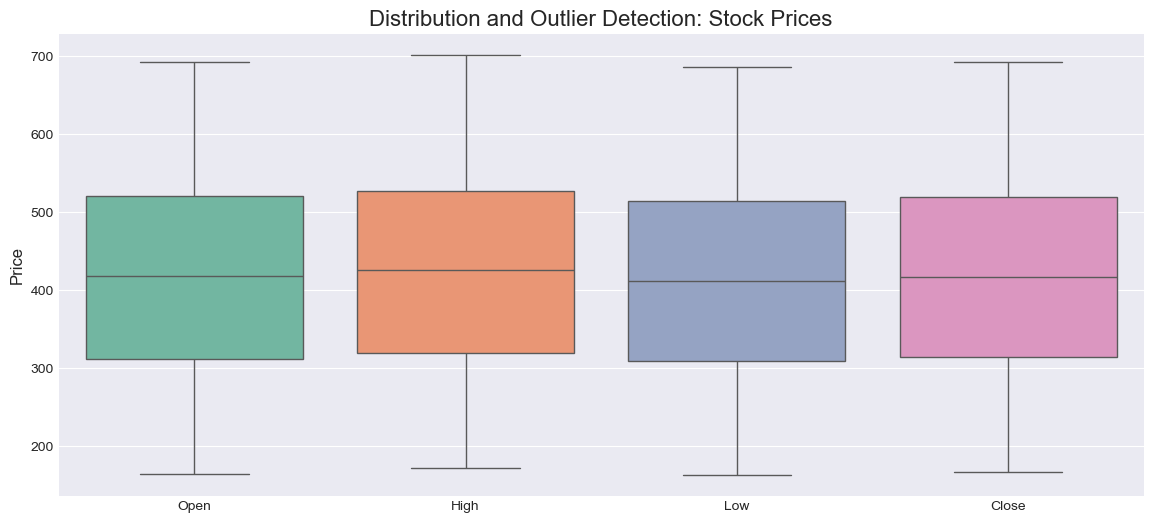

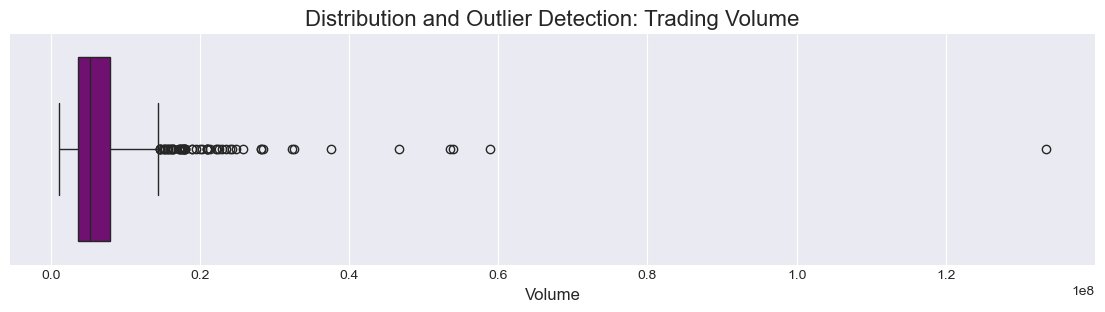

In [4]:
plt.figure(figsize=(14, 6))

# Plotting boxplots for price columns
sns.boxplot(data=df[['Open', 'High', 'Low', 'Close']], palette="Set2")
plt.title('Distribution and Outlier Detection: Stock Prices', fontsize=16)
plt.ylabel('Price', fontsize=12)
plt.show()

# Separate boxplot for Volume due to scale difference
plt.figure(figsize=(14, 3))
sns.boxplot(x=df['Volume'], color='purple')
plt.title('Distribution and Outlier Detection: Trading Volume', fontsize=16)
plt.xlabel('Volume', fontsize=12)
plt.show()

 
Boxplots visualize the distribution of data points and highlight statistical outliers (dots outside the whiskers).

What can be done: In financial data, "outliers" often represent significant external market events. We will keep these outliers rather than deleting them, as predicting high volatility is a core part of forecasting

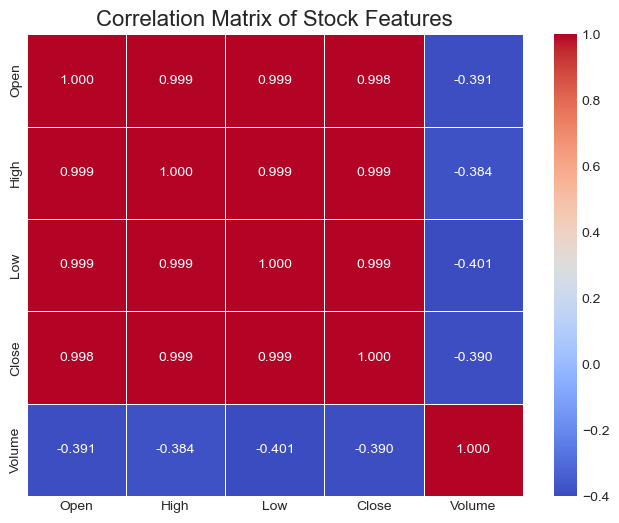

In [5]:
plt.figure(figsize=(8, 6))

# Calculate the correlation matrix
corr_matrix = df[['Open', 'High', 'Low', 'Close', 'Volume']].corr()

# Plot the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".3f", linewidths=0.5)
plt.title('Correlation Matrix of Stock Features', fontsize=16)
plt.show()

 A heatmap showing the Pearson correlation between numerical variables.
What can be done: There is near-perfect correlation (>0.99) among Open, High, Low, and Close. To prevent multicollinearity issues in linear models, we will focus heavily on predicting the Close price using engineered lag features, or we will utilize tree-based models which handle multicollinearity well.

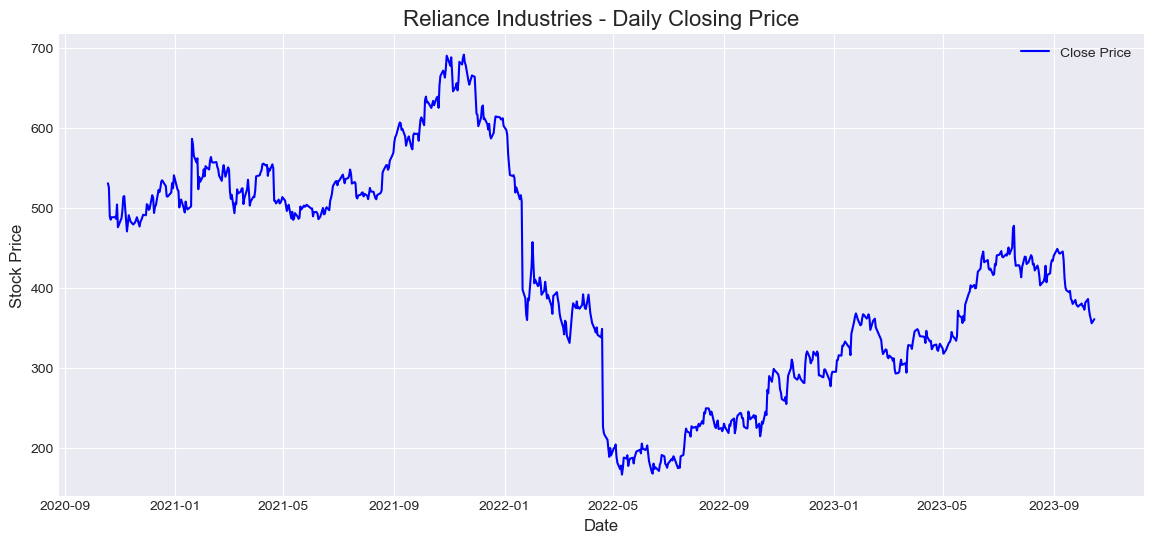

In [6]:
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Close'], label='Close Price', color='blue', linewidth=1.5)
plt.title('Reliance Industries - Daily Closing Price', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Stock Price', fontsize=12)
plt.legend()
plt.show()

What this graph represents: The foundational plot showing the raw Closing Price over time.
What can be done: We look for overall directionality, variance, and structural breaks—sudden massive drops or spikes which indicate how the stock is impacted by external factors.

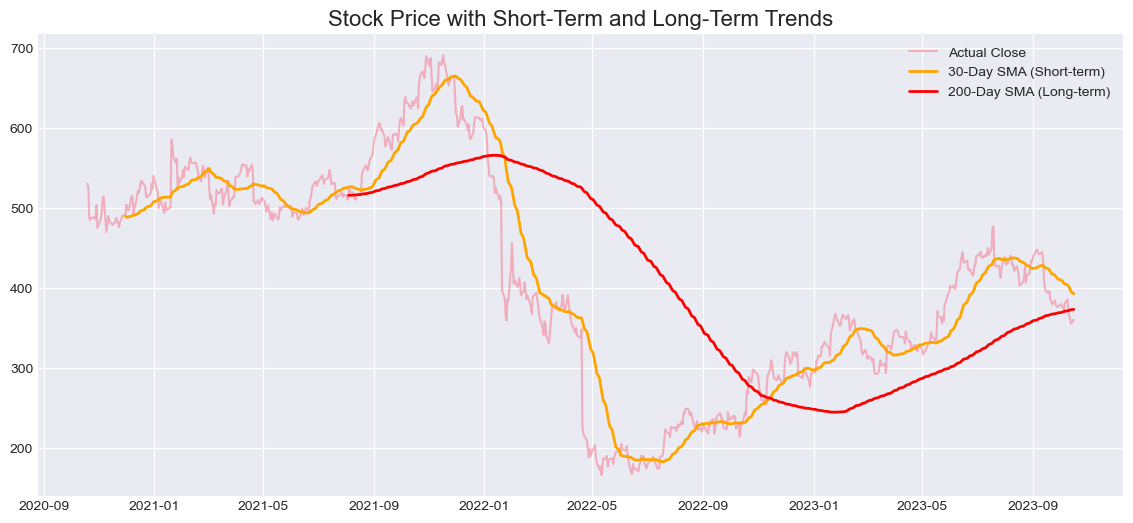

In [7]:
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Close'], label='Actual Close', alpha=0.5)

# Calculate 30-day and 200-day Simple Moving Averages (SMA)
df['SMA_30'] = df['Close'].rolling(window=30).mean()
df['SMA_200'] = df['Close'].rolling(window=200).mean()

plt.plot(df.index, df['SMA_30'], label='30-Day SMA (Short-term)', color='orange', linewidth=2)
plt.plot(df.index, df['SMA_200'], label='200-Day SMA (Long-term)', color='red', linewidth=2)

plt.title('Stock Price with Short-Term and Long-Term Trends', fontsize=16)
plt.legend()
plt.show()

What this graph represents: This isolates the short-term and long-term trends by overlaying 30-day and 200-day rolling averages.
What can be done: Crossings of these lines (Golden Cross / Death Cross) are strong signals of momentum shifts, which our machine learning models will learn from the rolling window features we create next.

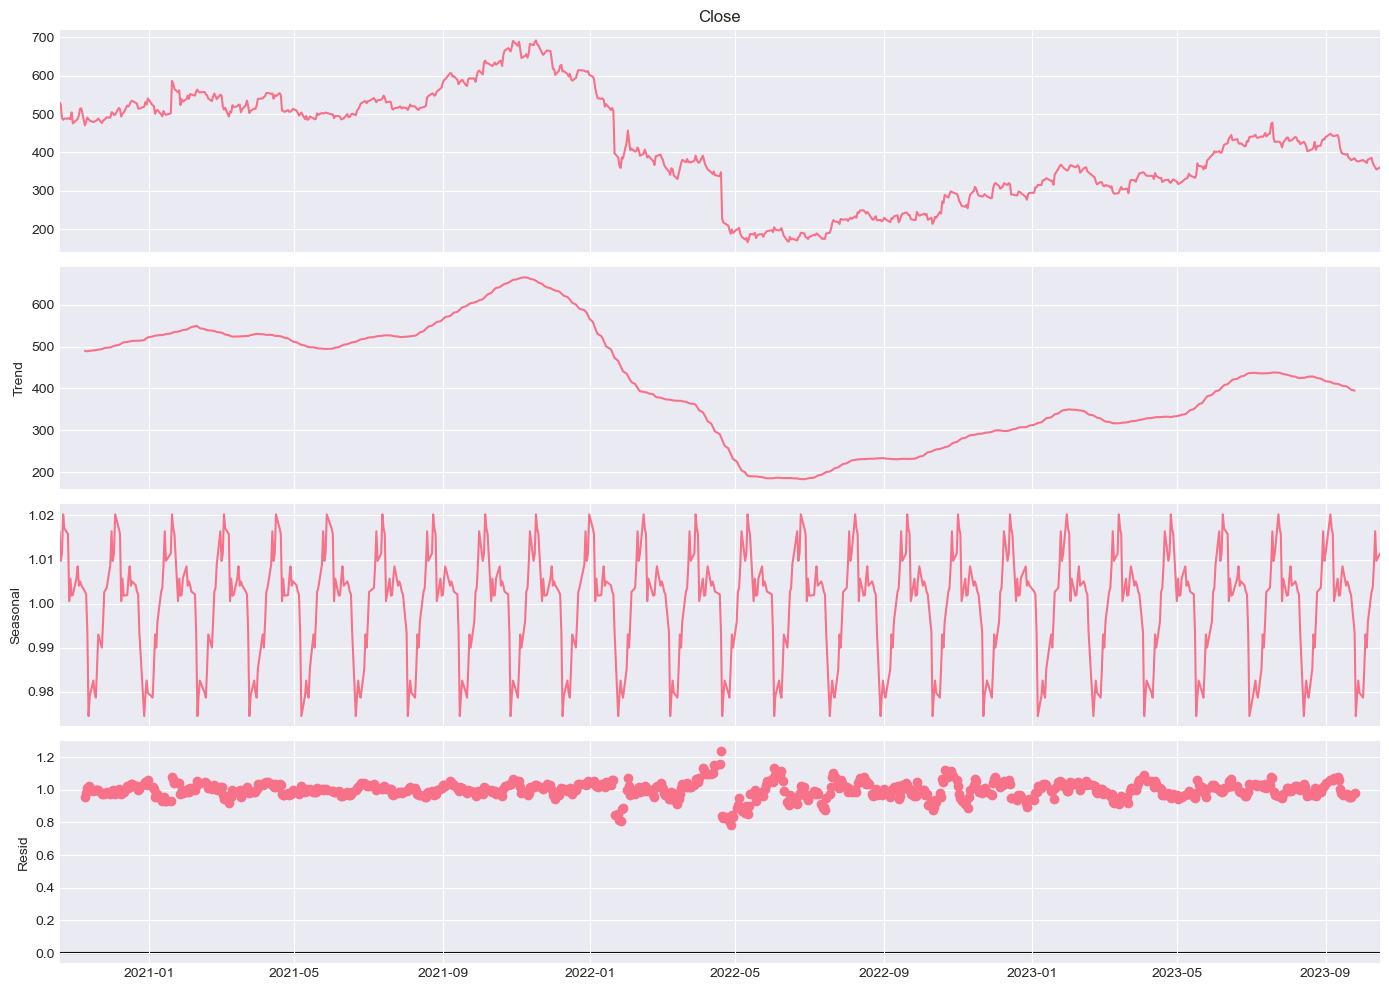

In [8]:
# Decompose the time series to isolate Trend, Seasonality, and Residuals
decomposition = seasonal_decompose(df['Close'].dropna(), model='multiplicative', period=30)

fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.tight_layout()
plt.show()

What this graph represents: Breaks the data into overarching Trend, repeating Seasonal patterns, and Residual "noise".
What can be done: Spikes in the Residual plot indicate exact dates of external shock.
Evidence of seasonality dictates that we must create calendar-based features (month, day of week) for our model.

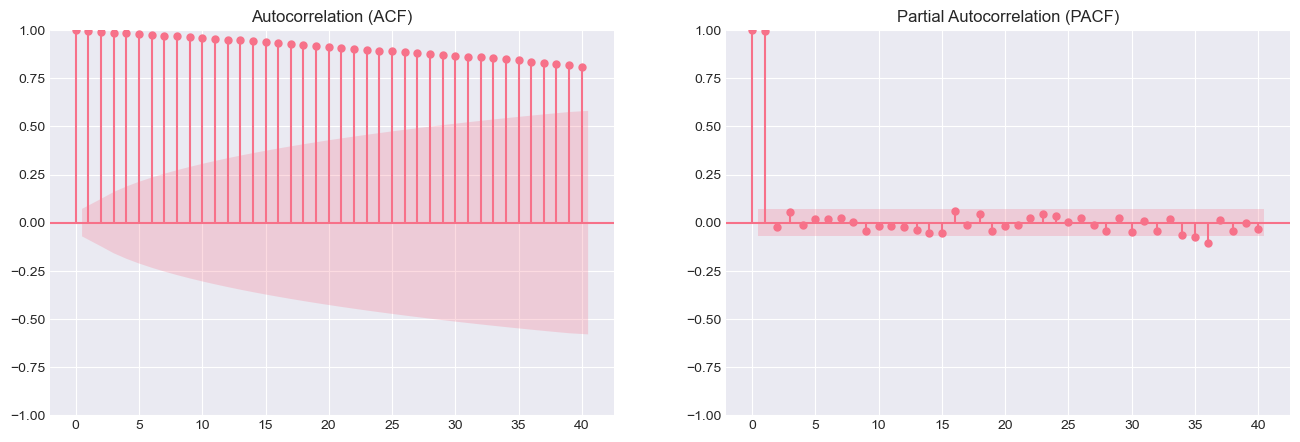

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ACF
plot_acf(df['Close'].dropna(), lags=40, ax=axes[0], title='Autocorrelation (ACF)')
# PACF
plot_pacf(df['Close'].dropna(), lags=40, ax=axes[1], title='Partial Autocorrelation (PACF)')

plt.show()

What this graph represents:

ACF shows correlation with past prices.

PACF shows direct correlation with past prices, removing intermediate influences.
What can be done: PACF tells us exactly how many "Lag" features to build. The sharp drop-off usually seen after Lag 1 or 2 in stock prices means the immediately preceding days carry the most predictive power.

In [10]:
# Create a copy for feature engineering
df_features = df.copy()

# 1. Lag Features (Based on PACF)
df_features['Close_Lag1'] = df_features['Close'].shift(1)
df_features['Close_Lag3'] = df_features['Close'].shift(3)
df_features['Close_Lag7'] = df_features['Close'].shift(7)

# 2. Rolling Window Statistics (Volatility & Momentum)
df_features['Rolling_Std_7'] = df_features['Close'].rolling(window=7).std()
df_features['Rolling_Mean_7'] = df_features['Close'].rolling(window=7).mean()

# 3. Price Volatility / Range Features
df_features['Intraday_Volatility'] = df_features['High'] - df_features['Low']
df_features['Daily_Return_Dir'] = df_features['Close'] - df_features['Open']

# 4. Percentage Returns (Stationarity)
df_features['Daily_Return_Pct'] = df_features['Close'].pct_change() * 100

# 5. Date/Time Features (Capturing Seasonality)
df_features['Day_of_Week'] = df_features.index.dayofweek
df_features['Month'] = df_features.index.month

# Drop NaN values generated by shifting and rolling windows
df_features.dropna(inplace=True)

display(df_features.head())

,Open,High,Low,Close,Adj close,Volume,SMA_30,SMA_200,Close_Lag1,Close_Lag3,Close_Lag7,Rolling_Std_7,Rolling_Mean_7,Intraday_Volatility,Daily_Return_Dir,Daily_Return_Pct,Day_of_Week,Month
Date,,,,,,,,,,,,,,,,,,
2021-08-04,513.000000,517.979980,510.369995,517.349976,517.349976,2039400,526.588333,516.401949,510.820007,517.570007,516.489990,3.000060,516.192854,7.609985,4.349976,1.278331,2,8
2021-08-05,517.130005,525.409973,514.020020,524.890015,524.890015,2556700,526.993334,516.372799,517.349976,515.150024,518.909973,4.418735,517.047145,11.389953,7.760010,1.457435,3,8
2021-08-06,524.000000,526.840027,519.390015,520.549988,520.549988,1919800,527.076334,516.348449,524.890015,510.820007,519.299988,4.548310,517.225717,7.450012,-3.450012,-0.826845,4,8
2021-08-09,521.150024,522.669983,517.989990,519.969971,519.969971,1367800,526.839666,516.503049,520.549988,517.349976,514.250000,4.437055,518.042855,4.679993,-1.180053,-0.111424,0,8
2021-08-10,520.000000,520.789978,512.969971,515.840027,515.840027,1960500,526.266666,516.656099,519.969971,524.890015,517.570007,4.515272,517.795715,7.820007,-4.159973,-0.794266,1,8


This transforms raw data into a predictive dataset. Lags look into the past, rolling statistics provide a "fear/volatility index", intraday volatility captures daily market battles, and time features allow the model to learn calendar trends.

In [11]:
# Project Requirement: Split the last year into a test set to build a model

# Find the maximum date in the dataset
max_date = df_features.index.max()

# Define the cutoff date as exactly 1 year prior to the max date
cutoff_date = max_date - pd.DateOffset(years=1)

# Split the data temporally (NEVER use random split for time series)
train_data = df_features[df_features.index <= cutoff_date]
test_data = df_features[df_features.index > cutoff_date]

print(f"Training Data Shape: {train_data.shape} | From {train_data.index.min().date()} to {train_data.index.max().date()}")
print(f"Testing Data Shape: {test_data.shape} | From {test_data.index.min().date()} to {test_data.index.max().date()}")

Training Data Shape: (303, 18) | From 2021-08-04 to 2022-10-14
Testing Data Shape: (251, 18) | From 2022-10-17 to 2023-10-16


In [12]:
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Training SARIMA Baseline Model...")

# SARIMA takes the raw, unscaled Close price. 
sarima_model = sm.tsa.statespace.SARIMAX(train_data['Close'], 
                                         order=(1, 1, 1), 
                                         seasonal_order=(1, 1, 1, 30),
                                         enforce_stationarity=False, 
                                         enforce_invertibility=False)

sarima_results = sarima_model.fit(disp=False)
sarima_forecast = sarima_results.get_forecast(steps=len(test_data))
test_data['SARIMA_Pred'] = sarima_forecast.predicted_mean

print("SARIMA Training Complete.")

Training SARIMA Baseline Model...
SARIMA Training Complete.


In [13]:
from xgboost import XGBRegressor

print("Training XGBoost Multivariate Model...")

# Define Features (X) and Target (y)
features = ['Close_Lag1', 'Close_Lag3', 'Close_Lag7', 'Rolling_Std_7', 
            'Rolling_Mean_7', 'Daily_Return_Pct', 'Day_of_Week', 'Month']

X_train = train_data[features]
y_train = train_data['Close']
X_test = test_data[features]
y_test = test_data['Close']

# XGBoost does not require feature scaling
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

test_data['XGBoost_Pred'] = xgb_model.predict(X_test)

print("XGBoost Training Complete.")

Training XGBoost Multivariate Model...
XGBoost Training Complete.


In [14]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

print("Training LSTM Model (Applying Data Transformation)...")

# 1. DATA TRANSFORMATION: We must scale the data for the Neural Network
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Reshape target to 2D array for the scaler
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

# 2. Reshape data for LSTM [samples, time steps, features]
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# 3. Build the LSTM Architecture
lstm_model = Sequential()
lstm_model.add(LSTM(50, activation='relu', return_sequences=True, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))
lstm_model.add(Dropout(0.2))
lstm_model.add(LSTM(50, activation='relu'))
lstm_model.add(Dense(1))

lstm_model.compile(optimizer='adam', loss='mse')

# 4. Train the model
lstm_model.fit(X_train_lstm, y_train_scaled, epochs=50, batch_size=32, verbose=0)

# 5. INVERSE TRANSFORMATION: Convert the scaled predictions (0 to 1) back into real stock prices (Rupees)
lstm_pred_scaled = lstm_model.predict(X_test_lstm)
test_data['LSTM_Pred'] = scaler_y.inverse_transform(lstm_pred_scaled)

print("LSTM Training Complete.")

Training LSTM Model (Applying Data Transformation)...
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
LSTM Training Complete.


Fixing Pandas indexing and creating Hybrid Model...

--- FINAL MODEL LEADERBOARD ---


,Model,RMSE,MAE,MAPE (%)
2,LSTM,19.859315,14.850263,4.490352
3,Hybrid,34.105403,26.203292,8.039435
1,XGBoost,52.703315,39.099858,11.955070
0,SARIMA,263.688367,234.612964,62.332029


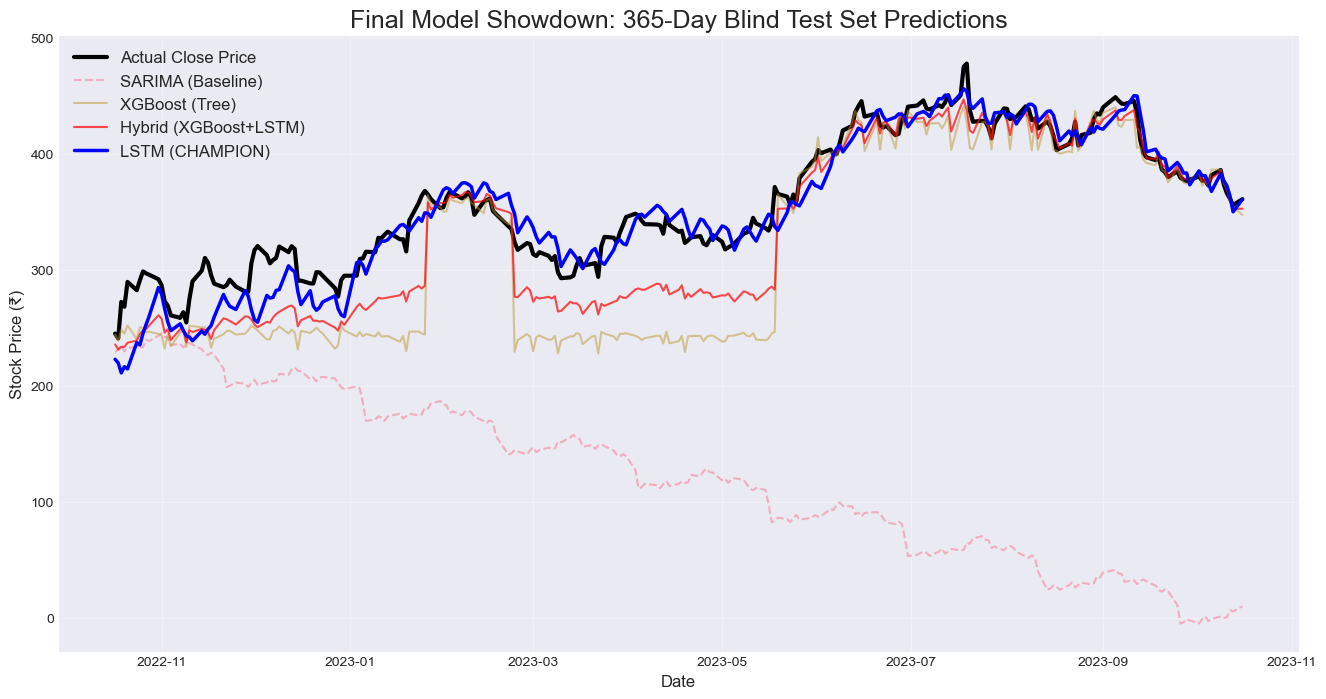

In [15]:
import pandas as pd
import numpy as np
import math
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt

print("Fixing Pandas indexing and creating Hybrid Model...")

# 1. THE FIX: Force the raw numbers into the dataframe, ignoring the index
test_data['SARIMA_Pred'] = sarima_forecast.predicted_mean.values
test_data['LSTM_Pred'] = scaler_y.inverse_transform(lstm_pred_scaled).flatten()

# 2. Build the Hybrid Model
test_data['Hybrid_Pred'] = (test_data['XGBoost_Pred'] * 0.6) + (test_data['LSTM_Pred'] * 0.4)

# 3. Drop any random NaN rows just to be absolutely safe before math
eval_df = test_data.dropna(subset=['Close', 'SARIMA_Pred', 'XGBoost_Pred', 'LSTM_Pred', 'Hybrid_Pred'])

# 4. Create the Evaluation Matrix using the clean dataframe
results = []
models_to_evaluate = ['SARIMA_Pred', 'XGBoost_Pred', 'LSTM_Pred', 'Hybrid_Pred']

for model in models_to_evaluate:
    rmse = math.sqrt(mean_squared_error(eval_df['Close'], eval_df[model]))
    mae = mean_absolute_error(eval_df['Close'], eval_df[model])
    mape = mean_absolute_percentage_error(eval_df['Close'], eval_df[model]) * 100
    results.append({'Model': model.replace('_Pred', ''), 'RMSE': rmse, 'MAE': mae, 'MAPE (%)': mape})

results_df = pd.DataFrame(results).sort_values(by='RMSE')
print("\n--- FINAL MODEL LEADERBOARD ---")
display(results_df)

# 5. Plot the Final "Showdown" Chart
plt.figure(figsize=(16, 8))
plt.plot(eval_df.index, eval_df['Close'], label='Actual Close Price', color='black', linewidth=3)

# Plotting the models
plt.plot(eval_df.index, eval_df['SARIMA_Pred'], label='SARIMA (Baseline)', alpha=0.5, linestyle='--')
plt.plot(eval_df.index, eval_df['XGBoost_Pred'], label='XGBoost (Tree)', alpha=0.5)
plt.plot(eval_df.index, eval_df['Hybrid_Pred'], label='Hybrid (XGBoost+LSTM)', color='red', alpha=0.7)

# --- ADDED THE CHAMPION LSTM ---
plt.plot(eval_df.index, eval_df['LSTM_Pred'], label='LSTM (CHAMPION)', color='blue', linewidth=2.5)
# -------------------------------

plt.title('Final Model Showdown: 365-Day Blind Test Set Predictions', fontsize=18)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Stock Price (₹)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

Generating 30-Day Future Forecast using Champion LSTM Model...


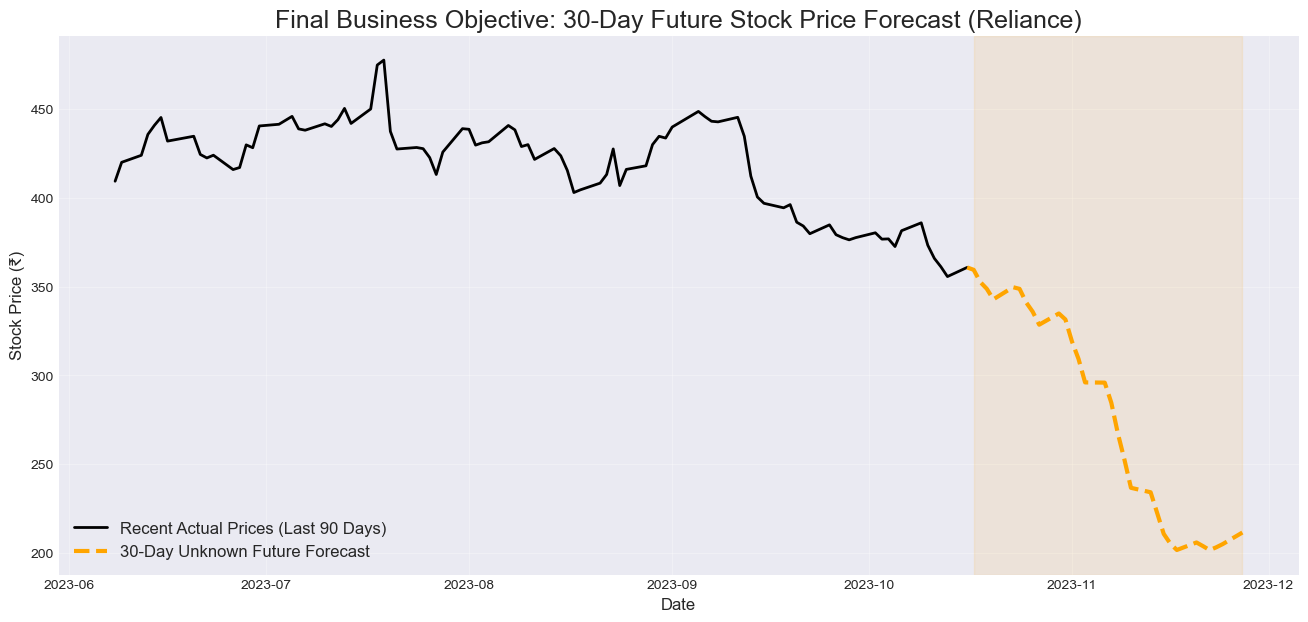


--- The Next 30 Days (Exact Predicted Values) ---


,LSTM_Future_Forecast
2023-10-17,359.479462
2023-10-18,352.642944
2023-10-19,348.787872
2023-10-20,342.847534
2023-10-23,349.696045
2023-10-24,348.762695
2023-10-25,341.180664
2023-10-26,335.912598
2023-10-27,328.580048
2023-10-30,334.891174


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Generating 30-Day Future Forecast using Champion LSTM Model...")

# 1. Grab the last 30 days of our test data to use as a starting point for our math
recent_data = test_data[['Close']].tail(30).copy()

# 2. Generate the calendar dates for the next 30 business days
last_date = recent_data.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=30, freq='B')

future_predictions = []

# 3. The Autoregressive Loop (Predict a day, add it to history, repeat)
for date in future_dates:
    # Calculate the features for 'tomorrow' based on the most recent data
    lag1 = recent_data['Close'].iloc[-1]
    lag3 = recent_data['Close'].iloc[-3]
    lag7 = recent_data['Close'].iloc[-7]
    roll_std = recent_data['Close'].tail(7).std()
    roll_mean = recent_data['Close'].tail(7).mean()
    
    prev_close = recent_data['Close'].iloc[-2]
    pct_change = ((lag1 - prev_close) / prev_close) * 100 if prev_close != 0 else 0
    
    day_of_week = date.dayofweek
    month = date.month
    
    # Create the feature array in the EXACT order the model was trained on
    X_future = np.array([[lag1, lag3, lag7, roll_std, roll_mean, pct_change, day_of_week, month]])
    
    # Scale the features using our previously fitted scaler
    X_future_scaled = scaler_X.transform(X_future)
    X_future_lstm = X_future_scaled.reshape((1, 1, X_future.shape[1]))
    
    # Predict the stock price
    pred_scaled = lstm_model.predict(X_future_lstm, verbose=0)
    pred_price = scaler_y.inverse_transform(pred_scaled)[0][0]
    
    # Save the prediction
    future_predictions.append(pred_price)
    
    # CRITICAL STEP: Append the newly predicted price to our recent_data 
    # so the loop can use it to calculate the lags for the next day
    recent_data.loc[date] = [pred_price]

# 4. Create a clean DataFrame for the final output
future_df = pd.DataFrame({'LSTM_Future_Forecast': future_predictions}, index=future_dates)

# 5. Plot the Final Business Forecast (The Money Chart)
plt.figure(figsize=(16, 7))

# Plot the last 90 days of actual historical data to give visual context
plt.plot(test_data.index[-90:], test_data['Close'].tail(90), label='Recent Actual Prices (Last 90 Days)', color='black', linewidth=2)

# --- THE FIX: Bridge the Gap ---
# Grab the very last actual date and price
last_actual_date = test_data.index[-1]
last_actual_price = test_data['Close'].iloc[-1]

# Temporarily glue that point to the front of the forecast purely for a seamless plot
plot_forecast = pd.concat([pd.Series({last_actual_date: last_actual_price}), future_df['LSTM_Future_Forecast']])
# -------------------------------

# Plot the 30-day future forecast using the bridged data
plt.plot(plot_forecast.index, plot_forecast, label='30-Day Unknown Future Forecast', color='orange', linewidth=3, linestyle='--')

plt.title('Final Business Objective: 30-Day Future Stock Price Forecast (Reliance)', fontsize=18)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Stock Price (₹)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

# Highlight the "Unknown Future" zone in light orange
plt.axvspan(future_df.index[0], future_df.index[-1], color='orange', alpha=0.1)
plt.show()

print("\n--- The Next 30 Days (Exact Predicted Values) ---")
display(future_df) 


future_df.to_csv("Reliance_30_Day_Forecast.csv")